## Setup

In [81]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [82]:
from tapas_gmm_modified.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm_modified.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm_modified.policy.models.tpgmm
from tapas_gmm_modified.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm_modified.utils.logging import setup_logger  # noqa: F401
from tapas_gmm_modified.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'PressButton'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [84]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [85]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([88, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([88]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([88, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([88, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([88, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([88, 3, 256, 256]), device=cpu, dtype=to

In [ ]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=20,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    gt_frames=[
        [0, 1],
        [0, 1],
    ],  # Example ground truth frames for testing
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=10,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [87]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 18:26:51.613 | INFO     |  Fitting AutoTPGMM
2025-08-16 18:26:51.614 | INFO     |  Segmenting trajectories


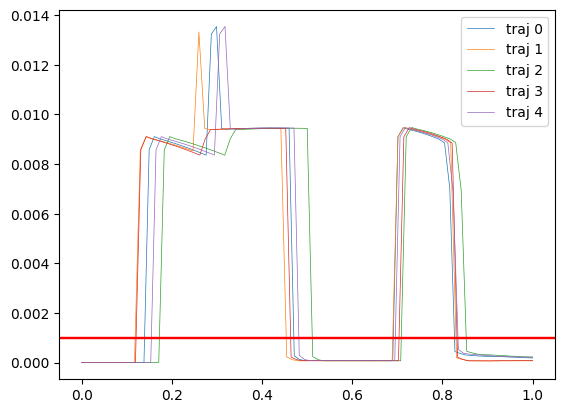

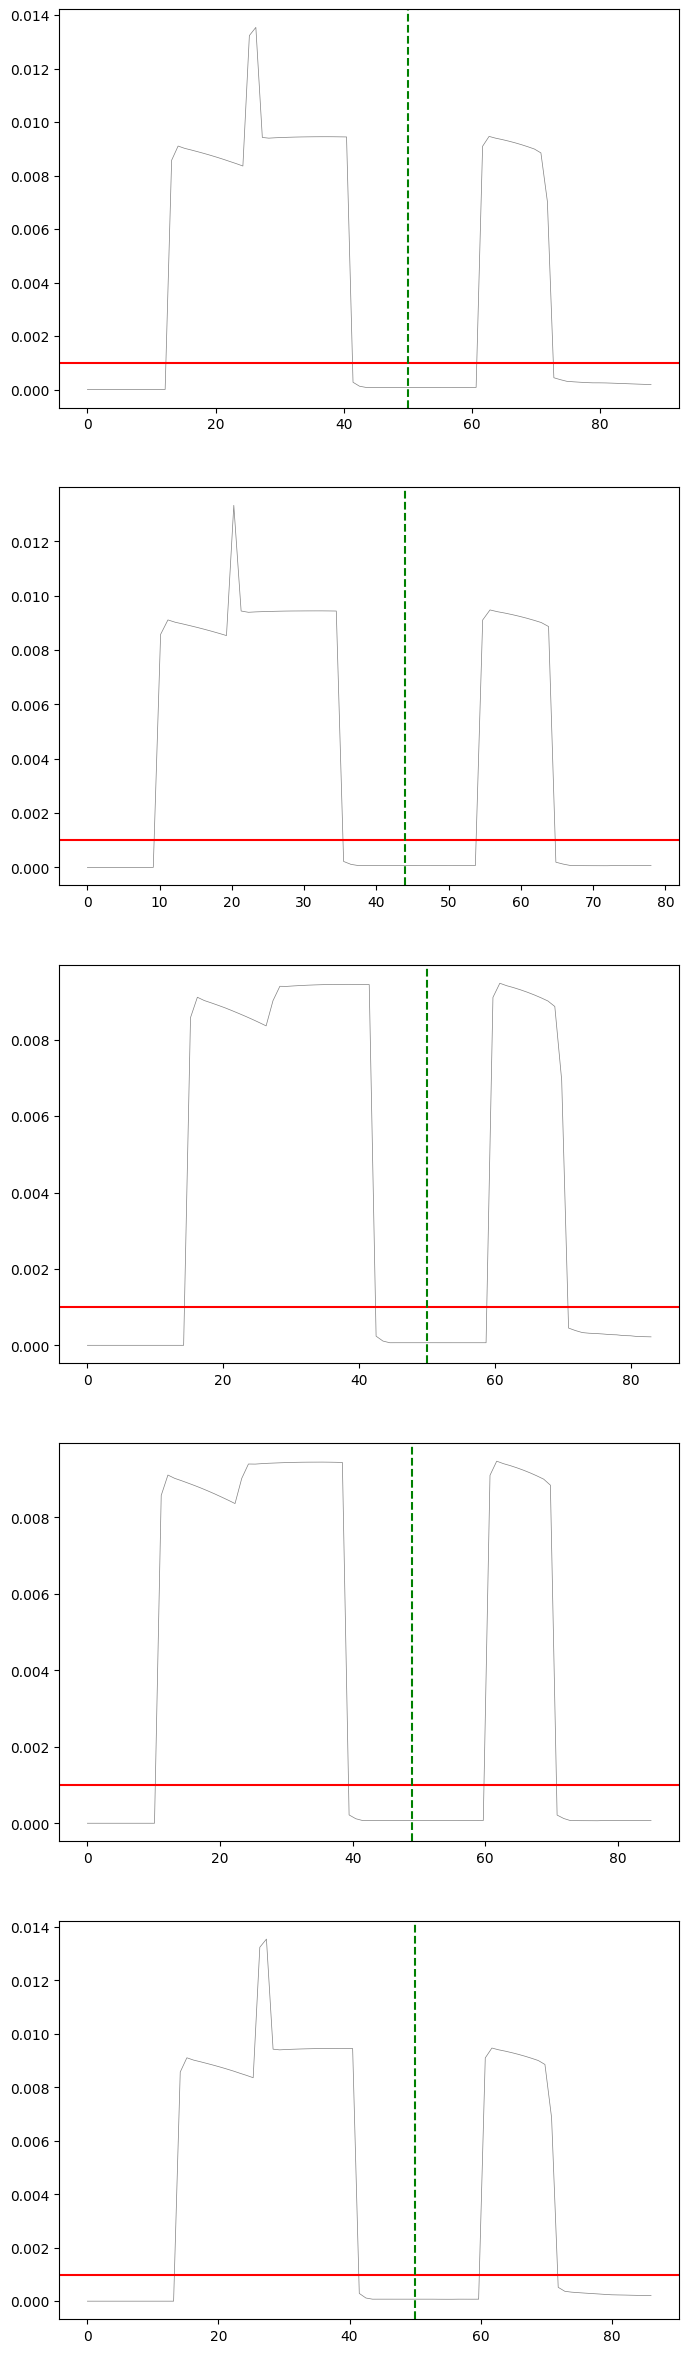

2025-08-16 18:26:51.834 | INFO     |  Creating segement of demos.
2025-08-16 18:26:51.836 | INFO     |  Creating segement of demos.
2025-08-16 18:26:51.838 | INFO     |  ... created 2 segments
2025-08-16 18:26:51.838 | INFO     |    Fitting candidate frame 1/10
2025-08-16 18:26:51.838 | INFO     |    Creating partial frame view of demos.
2025-08-16 18:26:51.840 | INFO     |    Changing number of components to 9


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2025-08-16 18:26:51.955 | INFO     |    Fitting candidate frame 2/10
2025-08-16 18:26:51.955 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2025-08-16 18:26:52.069 | INFO     |    Fitting candidate frame 3/10
2025-08-16 18:26:52.069 | INFO     |    Creating partial frame view of demos.


...

2025-08-16 18:26:54.210 | INFO     |  base__switch score (rel):     -0 (0.071)
2025-08-16 18:26:54.211 | INFO     |  Creating partial frame view of demos.
2025-08-16 18:26:54.211 | INFO     |  Segmented trajs into 2 segments
2025-08-16 18:26:54.213 | INFO     |  Frame score (abs):
            ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0 -0.247858     -0.247858     -0.004378    -0.007594     -0.020997   
Segment 1 -0.246329     -0.246021     -0.003542    -0.001610     -0.017567   

           block_blue    block_pink  block_red       led  lightbulb  
Segment 0   -0.000024 -4.258245e-06  -0.000009 -0.247858  -0.247858  
Segment 1   -0.000005 -6.828969e-07  -0.000005 -0.246021  -0.246033  
2025-08-16 18:26:54.215 | INFO     |  Frame score (rel):
           ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0      1.0      1.000000      0.017663     0.030640      0.084716   
Segment 1      1.0      0.998749      0.014379     0.006537   

Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

((array([[2.78e+023, 2.78e+023, 9.91e+022, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.01e+022, 2.63e+022, 5.53e+022, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [9.74e+013, 3.31e+015, 8.08e+016, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         ...,
         [1.92e-088, 6.77e-083, 1.46e-077, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.09e-187, 1.97e-182, 2.66e-177, ..., 3.63e+008, 2.26e+007,
          1.05e+006],
         [1.17e-143, 1.43e-141, 1.59e-139, ..., 3.82e+019, 2.81e+019,
          1.89e+019]]),
  array([[6.45e+022, 6.49e+022, 2.52e+022, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [2.47e+021, 5.66e+021, 1.10e+022, ..., 2.20e-101, 5.69e-104,
          1.25e-106],
         [3.93e+002, 1.31e+006, 1.91e+009, ..., 9.51e-061, 1.73e-068,
          1.38e-076],
         [6.70e+000, 4.46e+001, 2.27e+002, ..., 7.72e+000, 4.02e-002,
          1.60e-004],
         [5.94e-088, 1.22e-085, 2.12e-083, ..., 4.45e+017, 6.08e

In [88]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 18:26:54.639 | INFO     |  Did not specify time_based, deciding automatically.


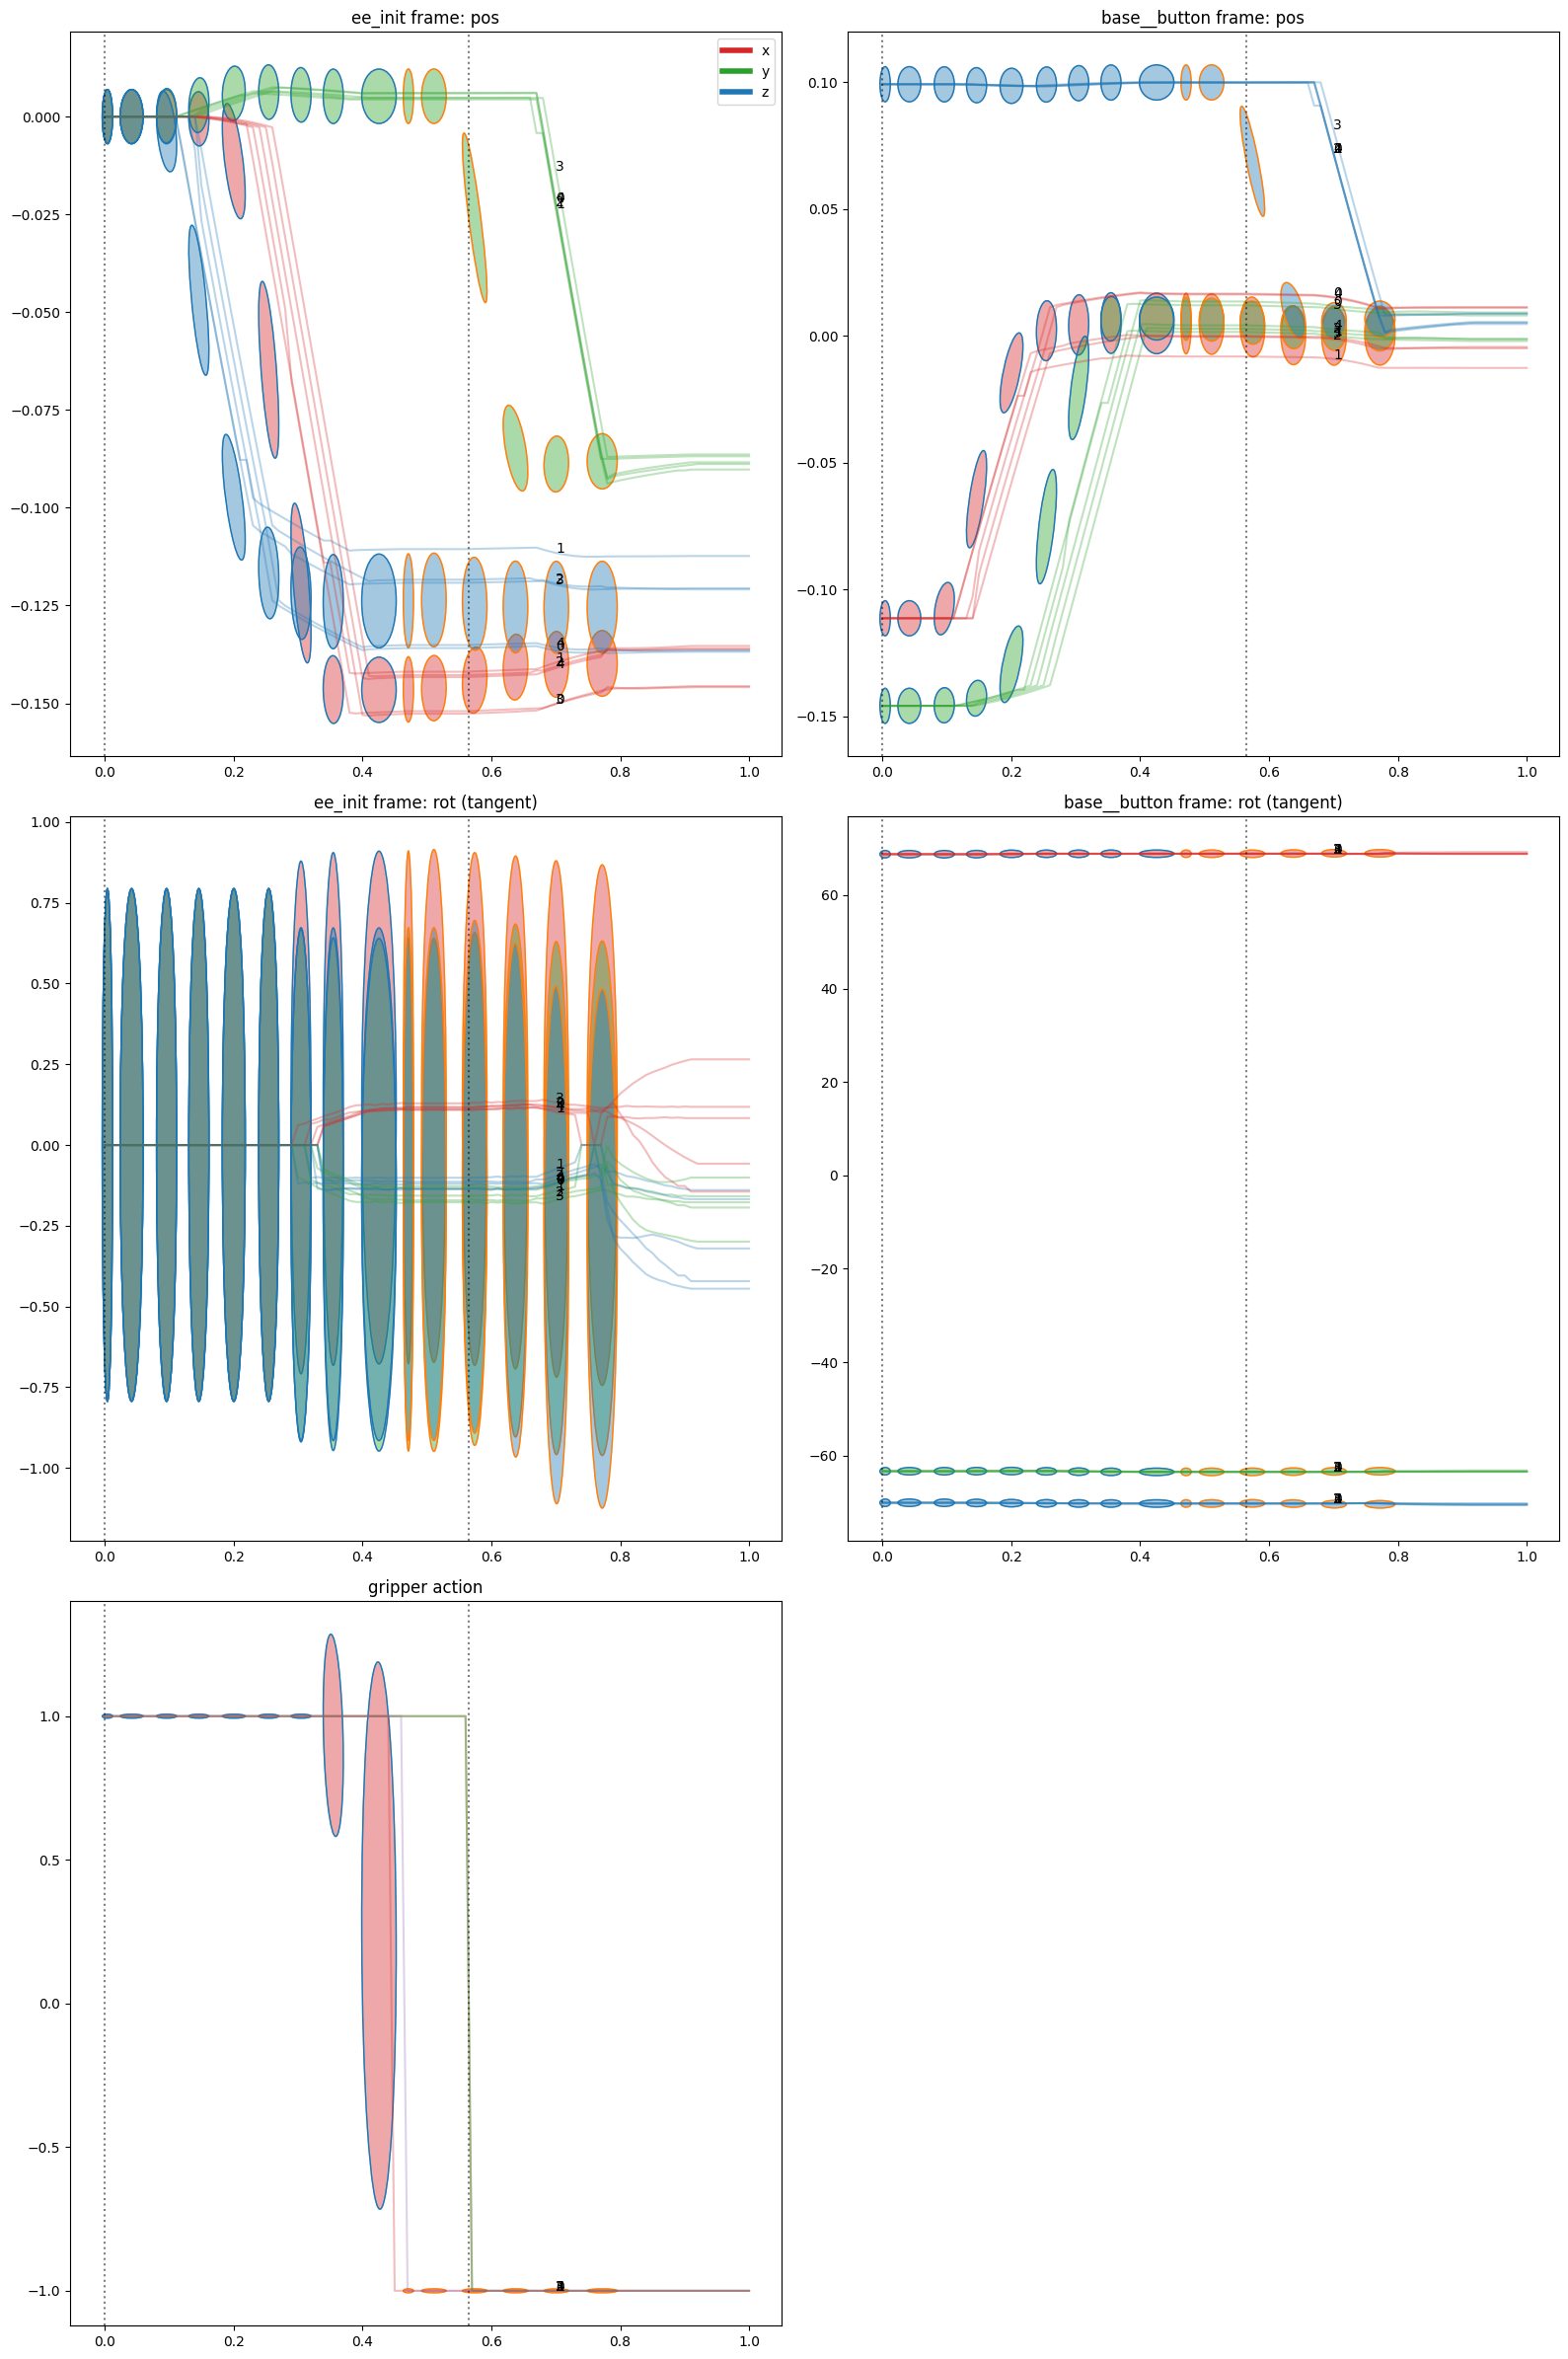

In [89]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [90]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 18:26:55.686 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+00, 1.00e+00, 1.00e+00, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         [0.00e+00, 2.80e-24, 4.79e-17, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         [0.00e+00, 0.00e+00, 4.15e-55, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         ...,
         [0.00e+00, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         [0.00e+00, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         [0.00e+00, 0.00e+00, 0.00e+00, ..., 1.00e+00, 1.00e+00, 1.00e+00]]),
  array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 1.82e-022, 1.22e-015, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 7.97e-043, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 5.70e-297, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 4.00e-146, 4.20e-165,
          3.32e-184],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.00e+000, 1.00e+000

2025-08-16 18:27:12.986 | INFO     |  Did not specify time_based, deciding automatically.


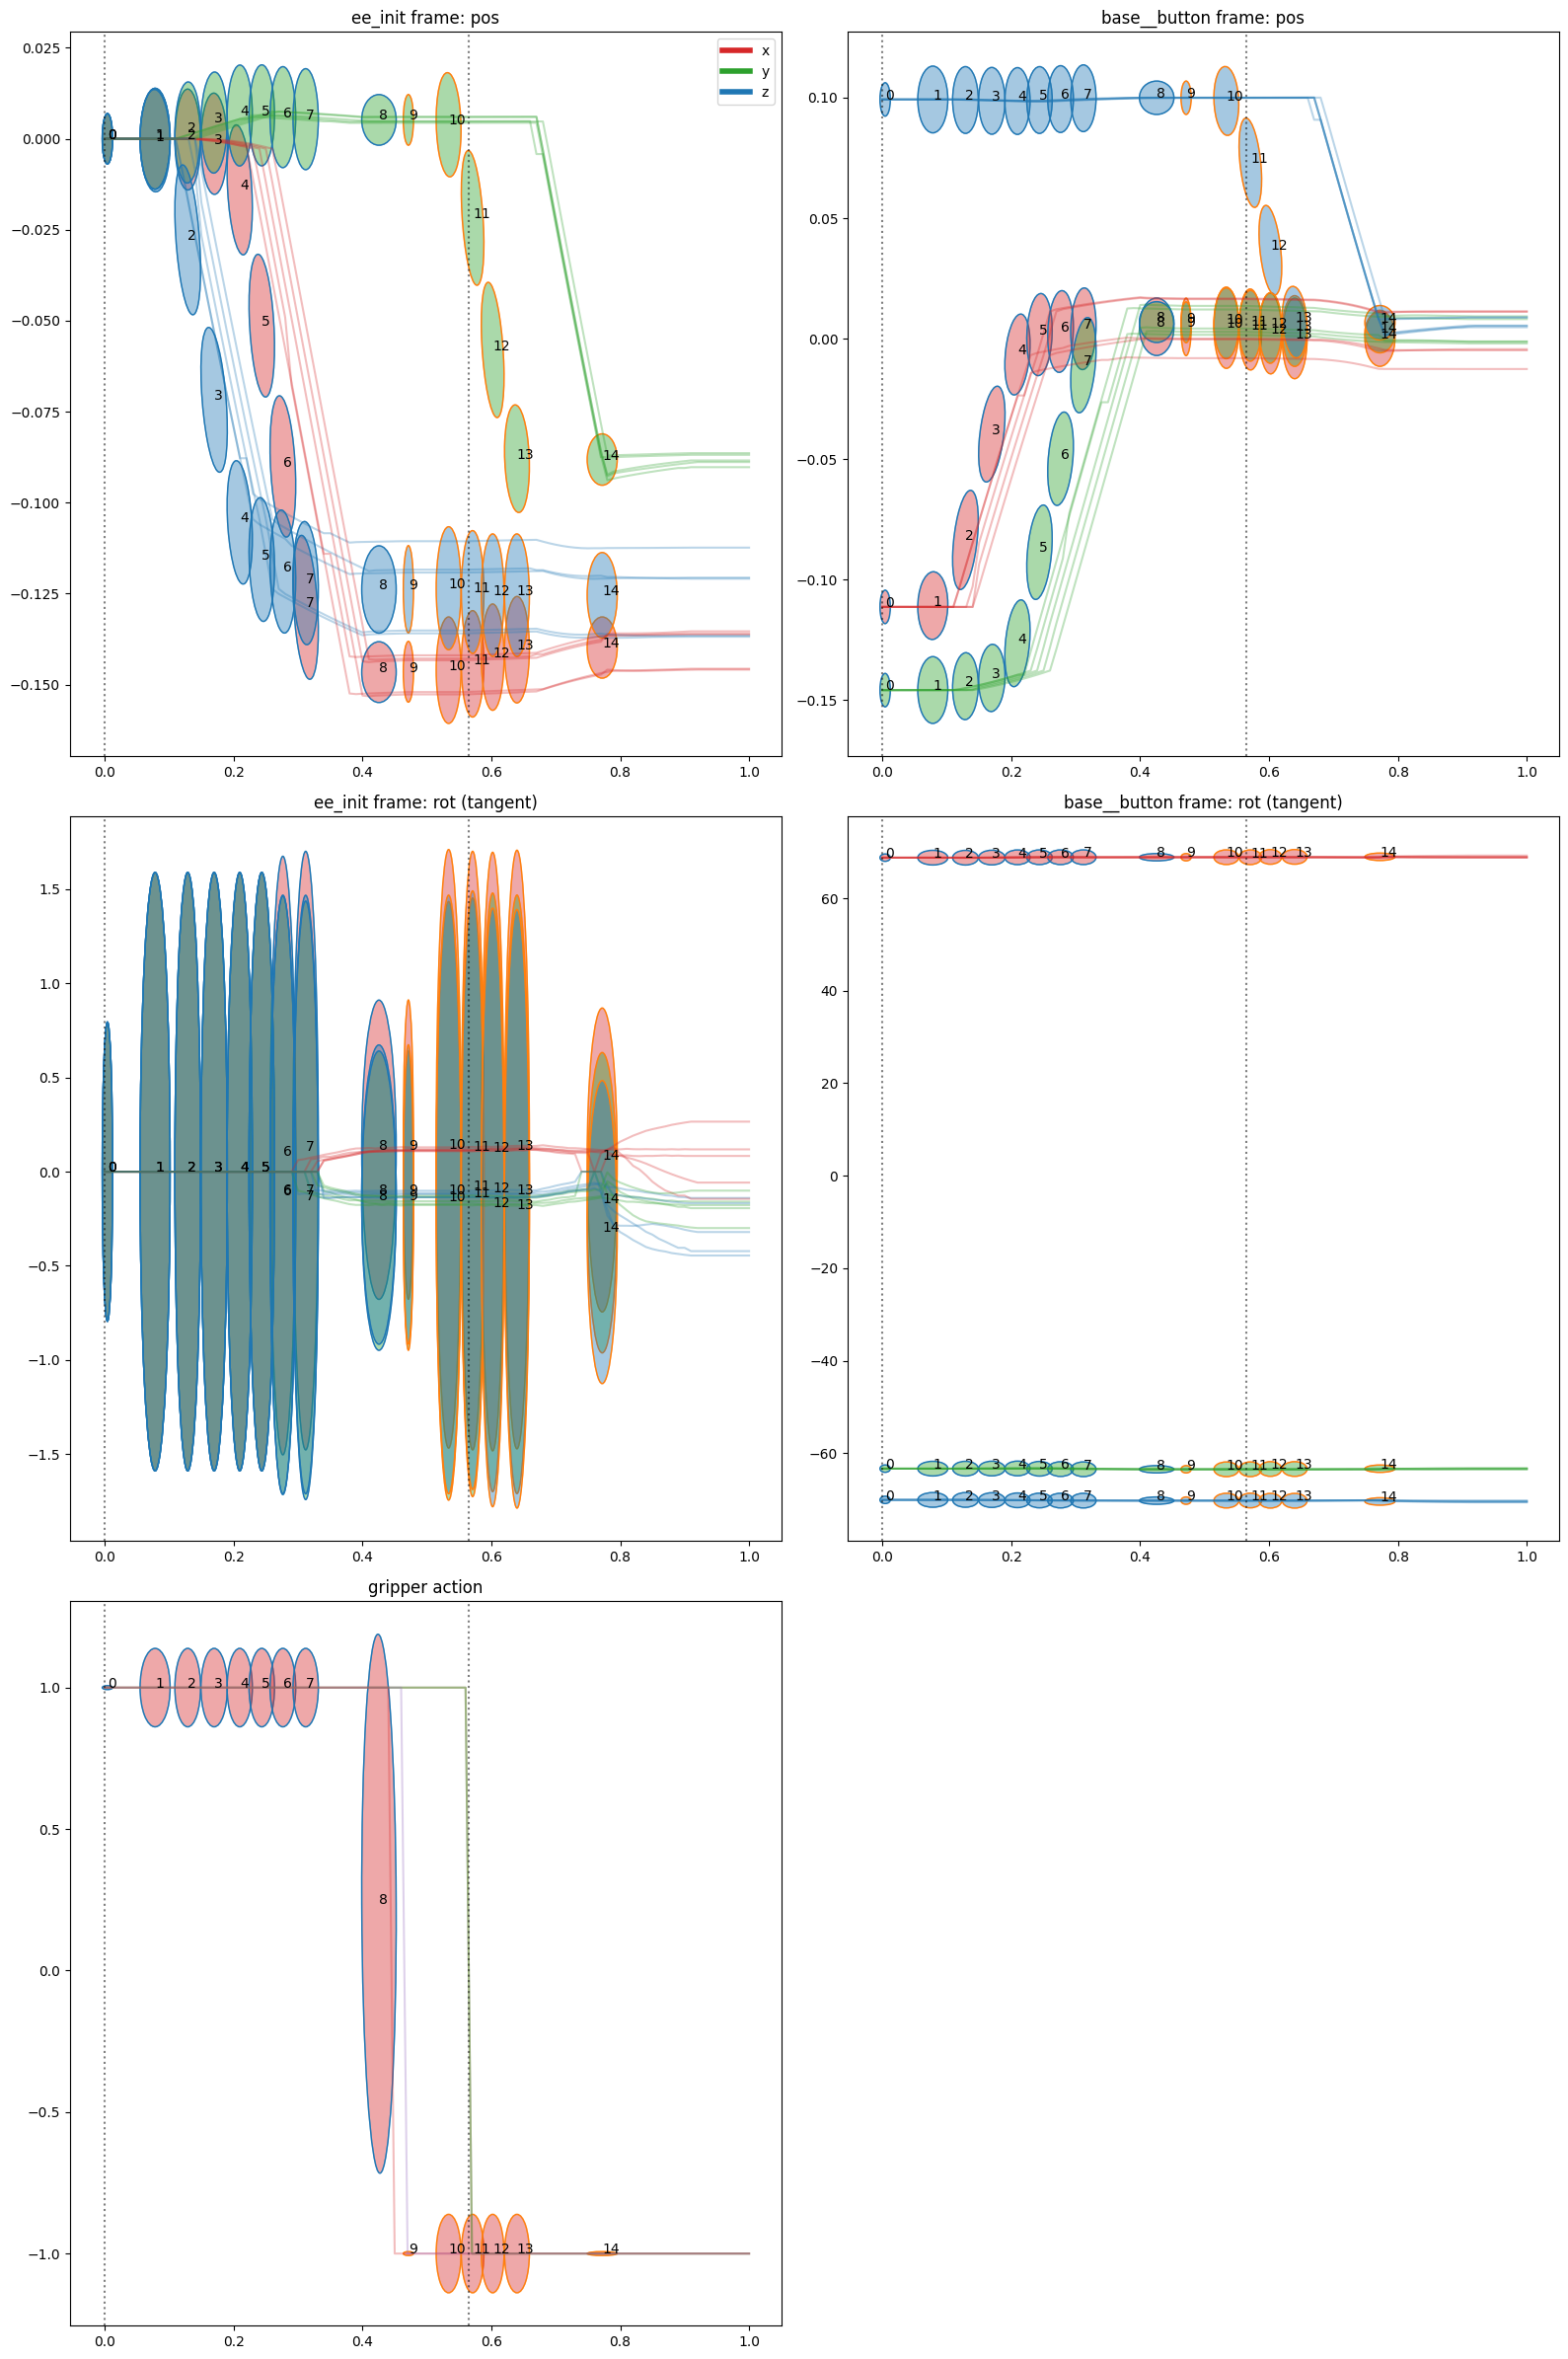

In [91]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

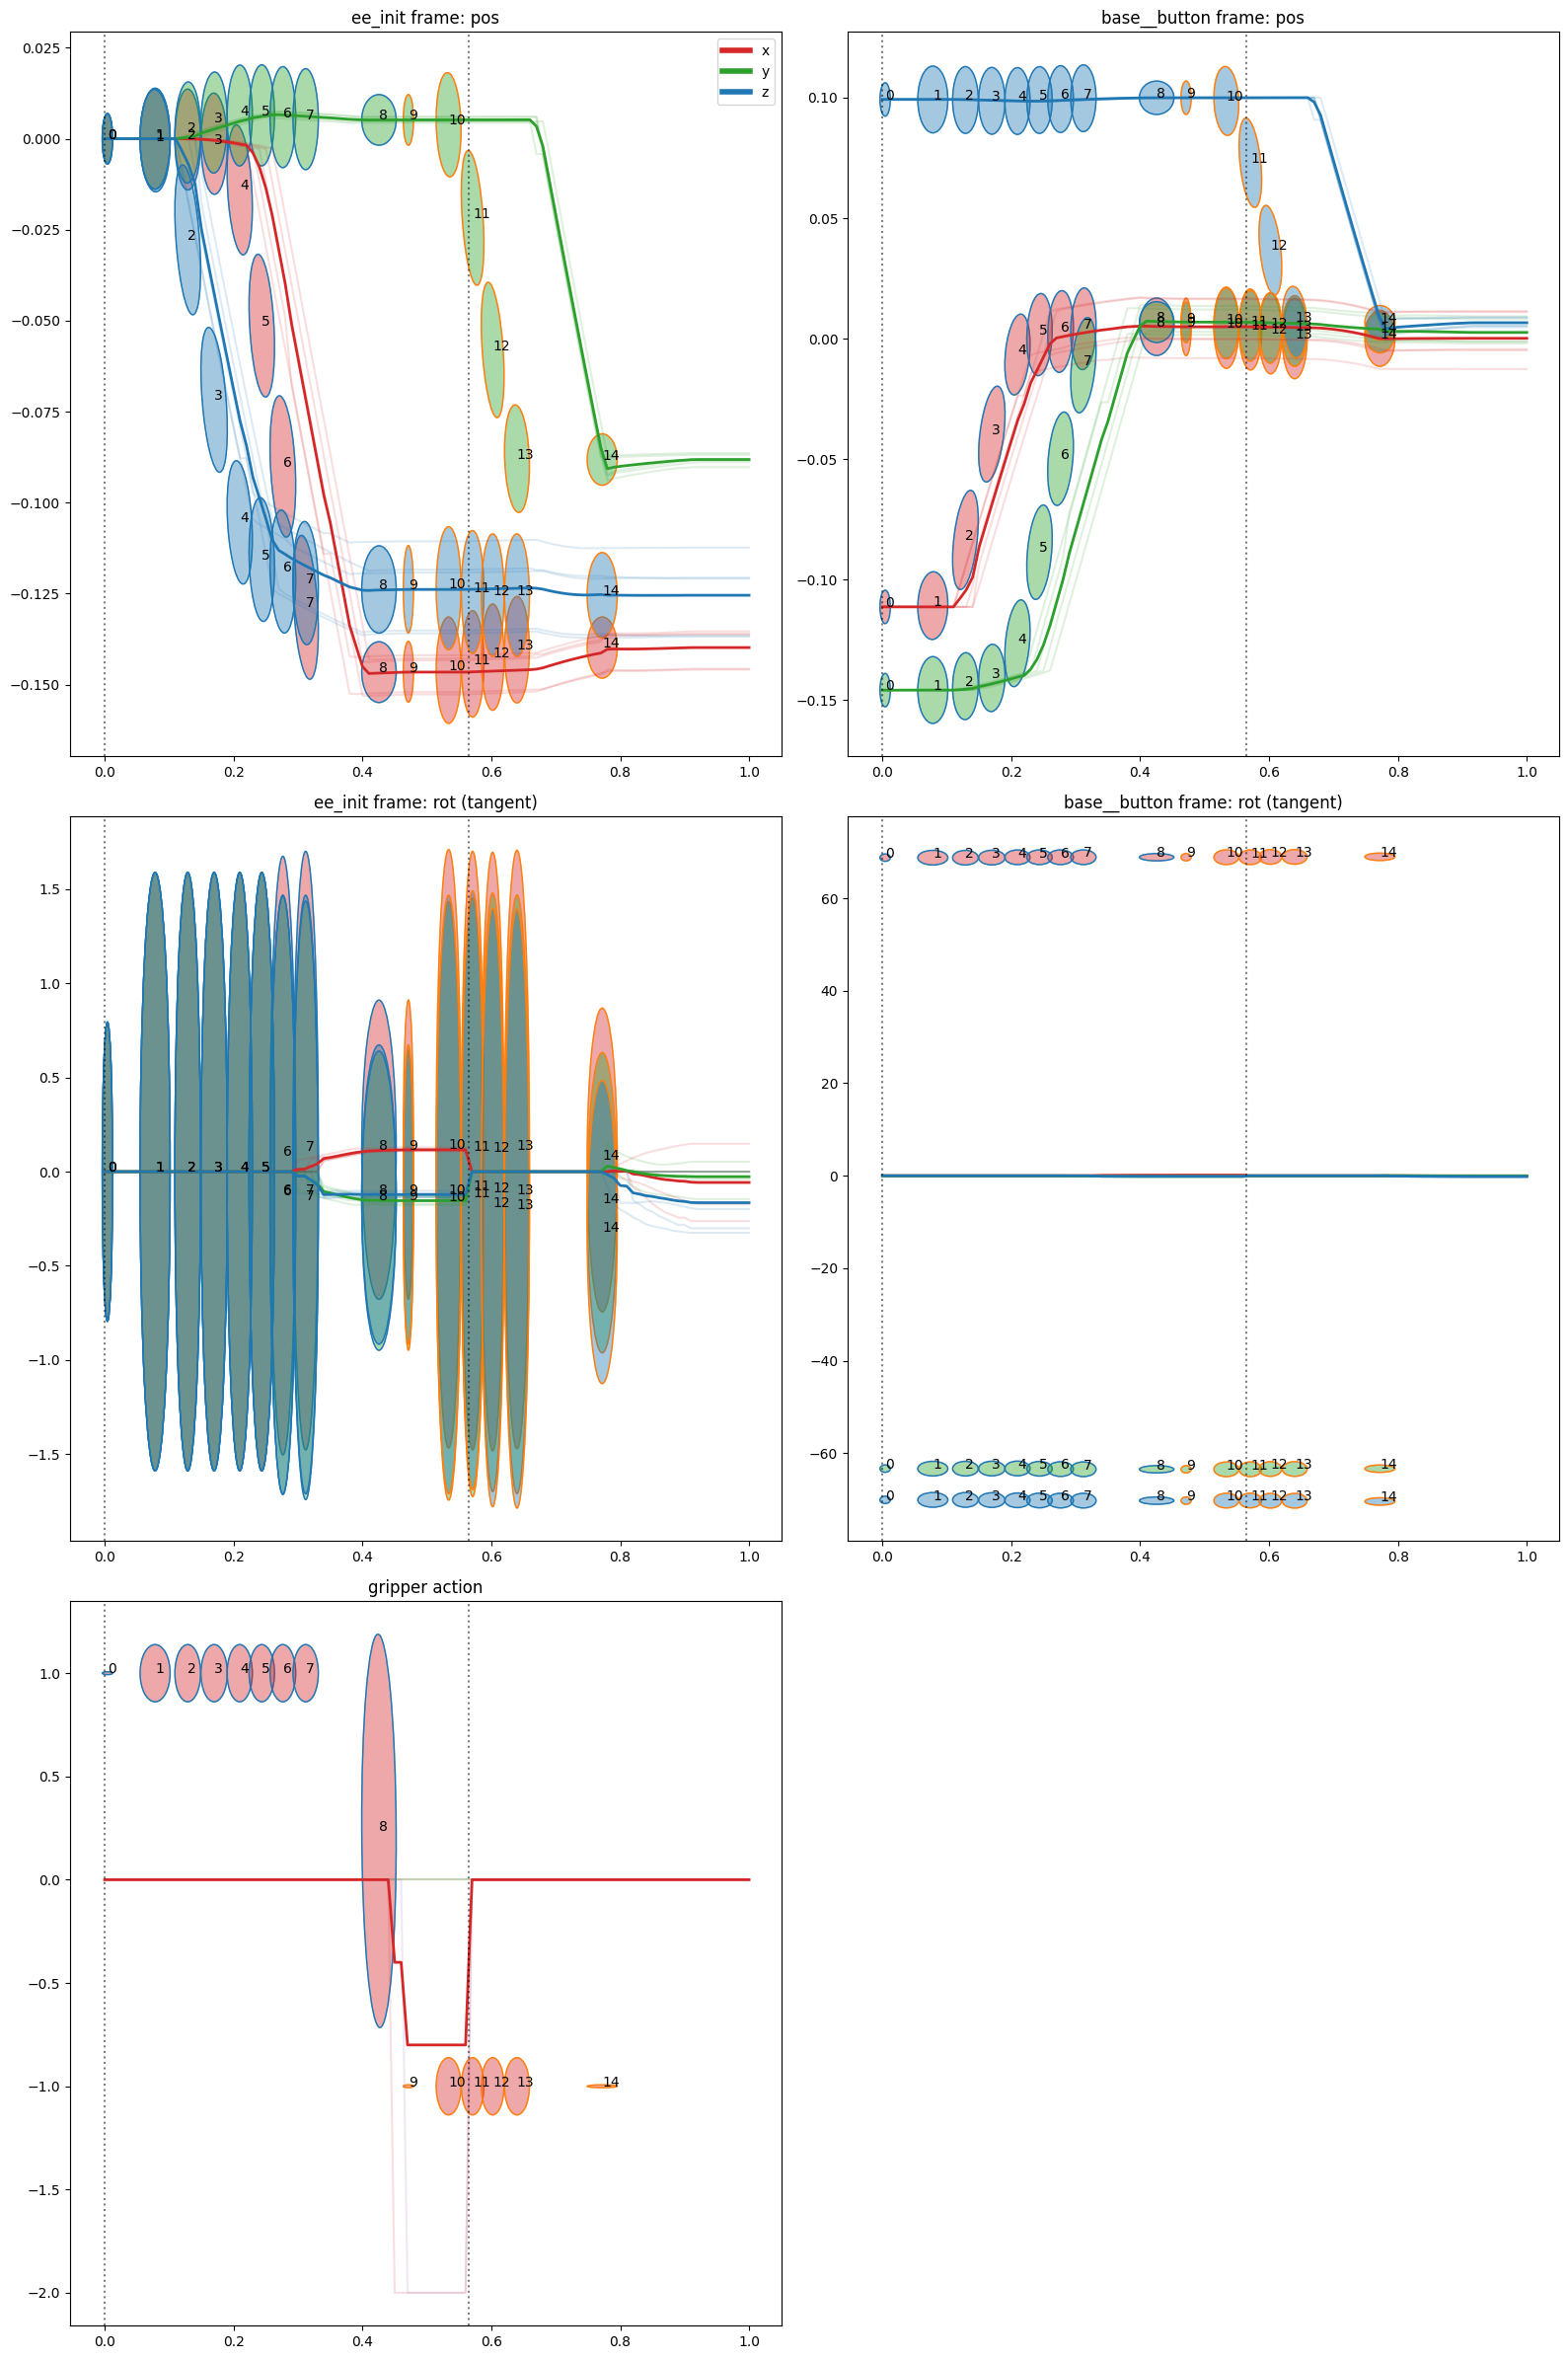

In [92]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

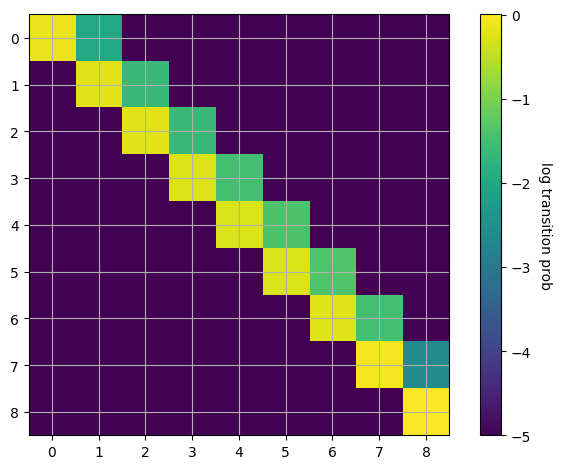

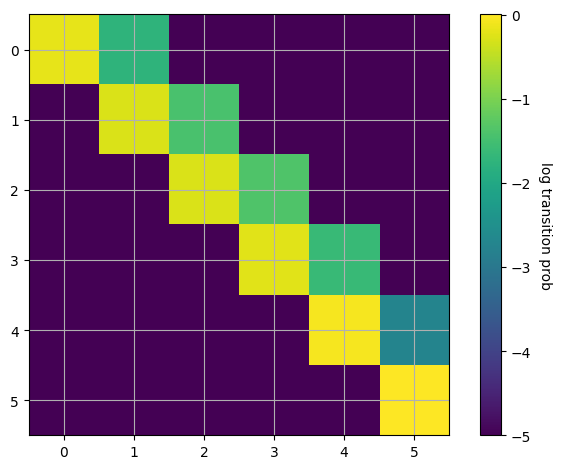

In [93]:
atpgmm.plot_hmm_transition_matrix()

In [94]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [95]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm_modified.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 18:27:24.700 | INFO     |  Caculated segment transition probabilities: (array([[2.23e-09]]),)
2025-08-16 18:27:24.700 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 18:27:24.753 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

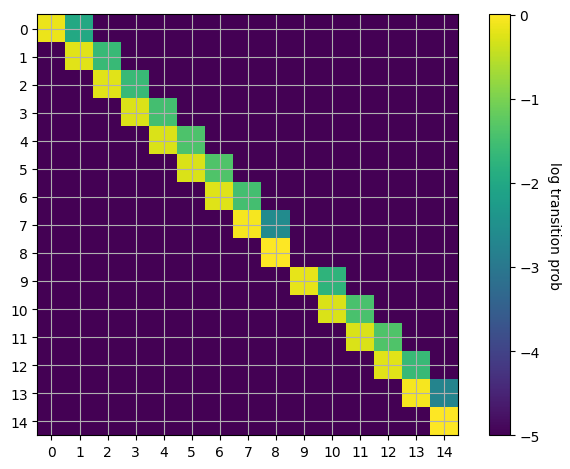

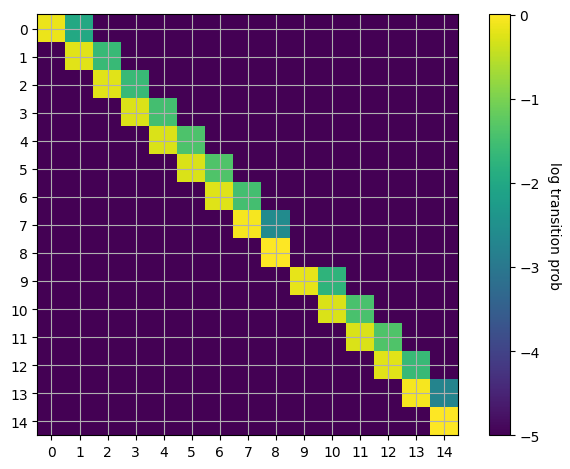

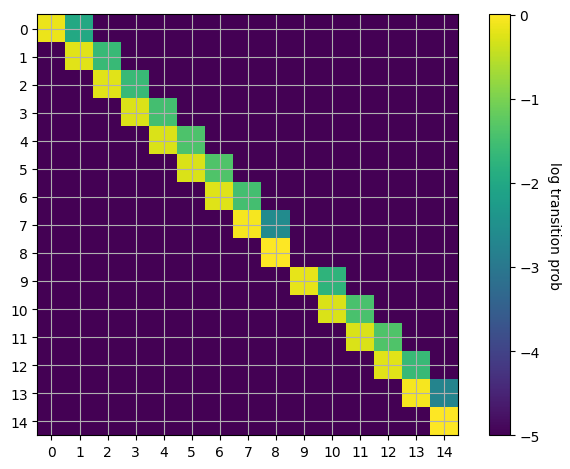

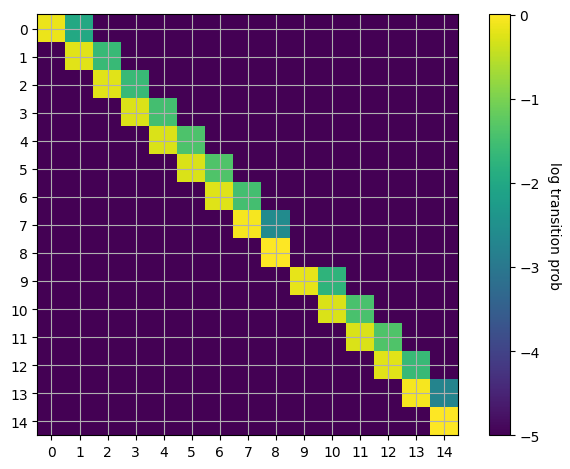

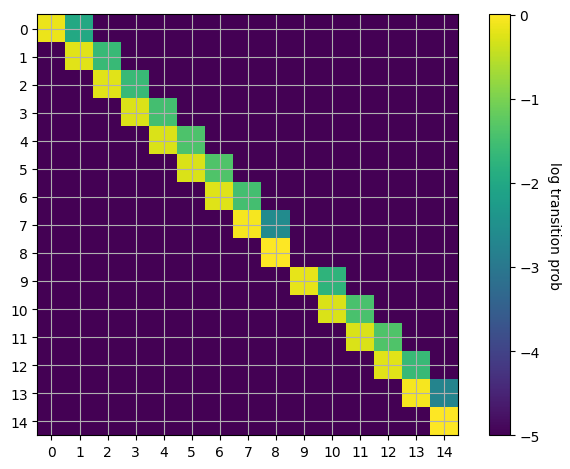

In [96]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 18:27:26.586 | INFO     |  Taking frame origins from demos.


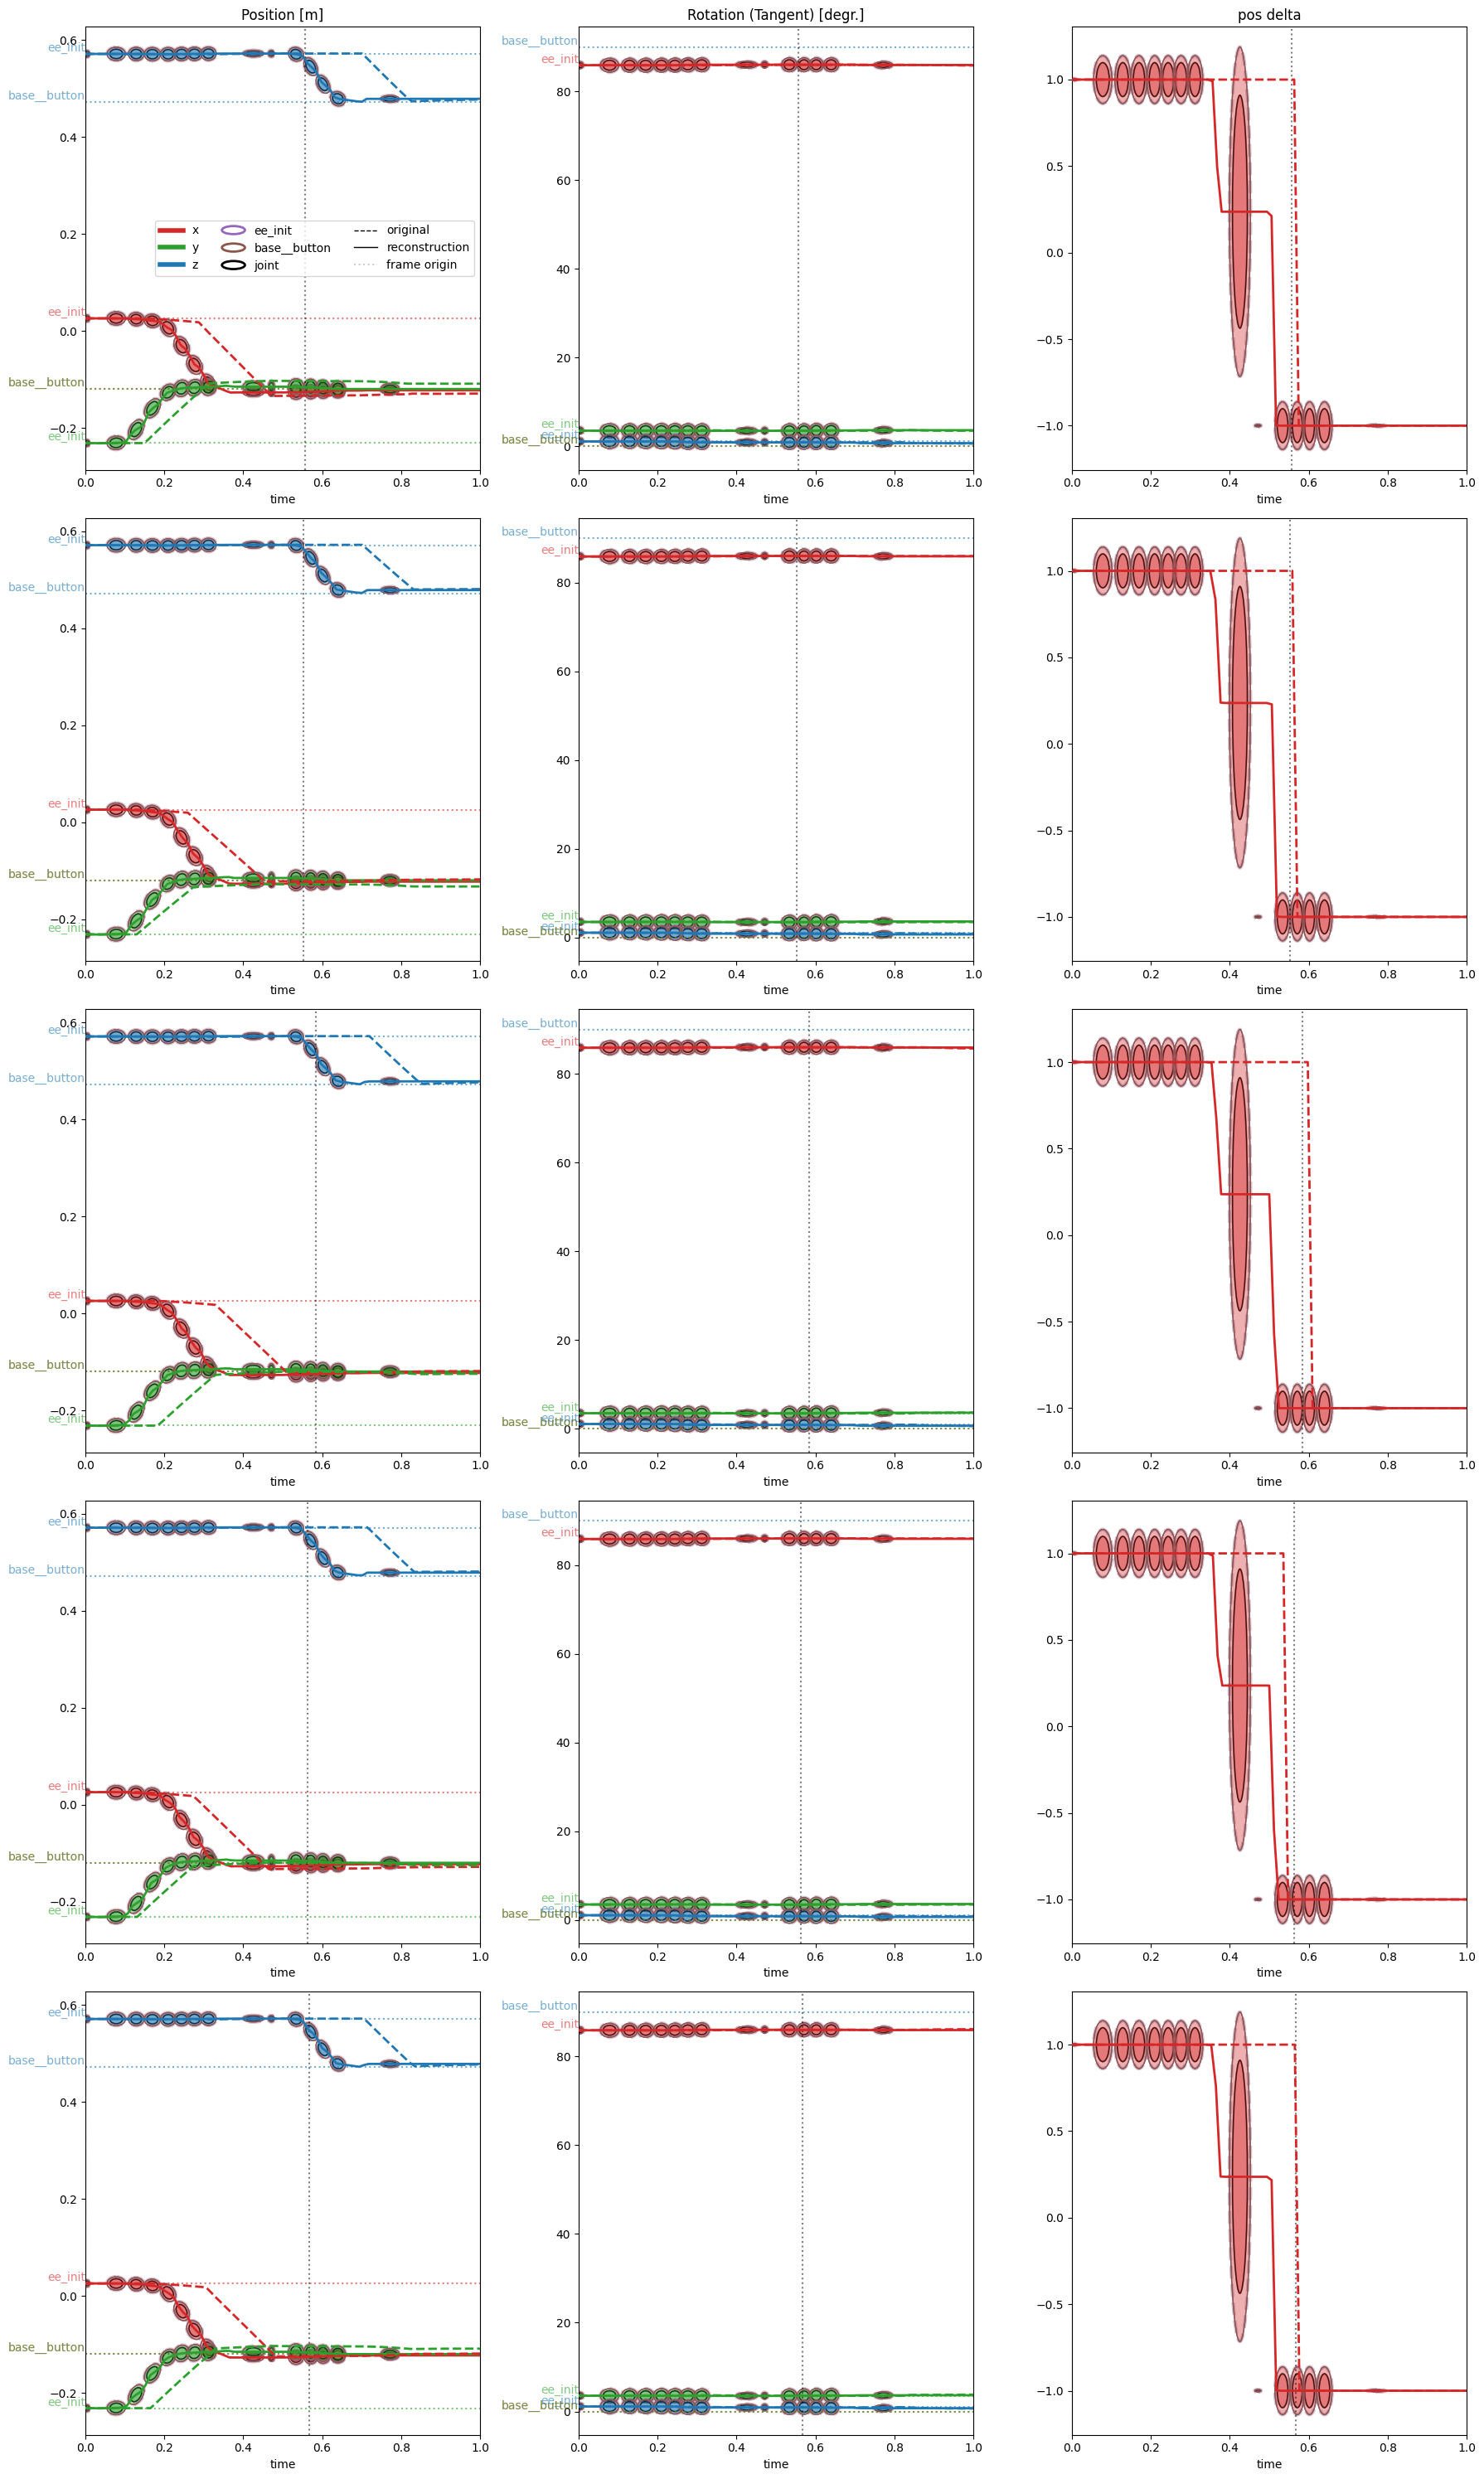

In [97]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [98]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

2025-08-16 18:27:31.657 | INFO     |  Taking frame origins from demos.


AttributeError: 'tuple' object has no attribute 'np_to_manifold_to_np'